# IS 5540 Project + Initial EDA

In [1]:
load_or_install <- function(pkgs) {
  for(p in pkgs) {
    if(!requireNamespace(p, quietly = TRUE)) {
      message(paste('Installing package:', p))
      install.packages(p)
    }
    library(p, character.only = TRUE)
  }
}

# load in tidyverse for data manip and plotting
# lubridate for handling date values
# scales for formatting for our plots
load_or_install(c('tidyverse', 'lubridate', 'scales'))

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors

Attaching package: ‘scales’

The following object is masked from ‘package:purrr’:

    discard

The following object is masked from ‘package:readr’:

    col_factor



Warning messages:
1: package ‘tidyverse’ was built under R version 4.5.3 
2: package ‘ggplot2’ was built under R version 4.5.3 
3: package ‘readr’ was built under R version 4.5.3 
4: package ‘purrr’ was built under R version 4.5.3 
5: package ‘dplyr’ was built under R version 4.5.3 
6: package ‘stringr’ was built under R version 4.5.3 


In [2]:
music <- read.csv("C:\\Users\\coolg\\OneDrive - Harding University\\Courses\\Spring 2026\\IS 5540\\spotify-tracks-dataset.csv") # load csv data

Note before dealing with the dataset: There were two columns, the
first title being blank and the second being titled "Unnamed."
The contents of both columns were just incrementing numbers. I went
ahead and deleted those columns in Excel, because they do not provide
any meaningful information for our data analysis. They would be useful for a
database, but not for our purposes.

In [3]:
head(music) # view first few rows for all attributes

                track_id                artists                                             album_name                 track_name popularity duration_ms
1 5SuOikwiRyPMVoIQDJUgSV            Gen Hoshino                                                 Comedy                     Comedy         73      230666
2 4qPNDBW1i3p13qLCt0Ki3A           Ben Woodward                                       Ghost (Acoustic)           Ghost - Acoustic         55      149610
3 1iJBSr7s7jYXzM8EGcbK5b Ingrid Michaelson;ZAYN                                         To Begin Again             To Begin Again         57      210826
4 6lfxq3CG4xtTiEg7opyCyx           Kina Grannis Crazy Rich Asians (Original Motion Picture Soundtrack) Can't Help Falling In Love         71      201933
5 5vjLSffimiIP26QG5WcN2K       Chord Overstreet                                                Hold On                    Hold On         82      198853
6 01MVOl9KtVTNfFiBU9I7dc           Tyrone Wells                                   

In [4]:
str(music) # structure of data frame

'data.frame':	114000 obs. of  20 variables:
 $ track_id        : chr  "5SuOikwiRyPMVoIQDJUgSV" "4qPNDBW1i3p13qLCt0Ki3A" "1iJBSr7s7jYXzM8EGcbK5b" "6lfxq3CG4xtTiEg7opyCyx" ...
 $ artists         : chr  "Gen Hoshino" "Ben Woodward" "Ingrid Michaelson;ZAYN" "Kina Grannis" ...
 $ album_name      : chr  "Comedy" "Ghost (Acoustic)" "To Begin Again" "Crazy Rich Asians (Original Motion Picture Soundtrack)" ...
 $ track_name      : chr  "Comedy" "Ghost - Acoustic" "To Begin Again" "Can't Help Falling In Love" ...
 $ popularity      : int  73 55 57 71 82 58 74 80 74 56 ...
 $ duration_ms     : int  230666 149610 210826 201933 198853 214240 229400 242946 189613 205594 ...
 $ explicit        : logi  FALSE FALSE FALSE FALSE FALSE FALSE ...
 $ danceability    : num  0.676 0.42 0.438 0.266 0.618 0.688 0.407 0.703 0.625 0.442 ...
 $ energy          : num  0.461 0.166 0.359 0.0596 0.443 0.481 0.147 0.444 0.414 0.632 ...
 $ key             : int  1 1 0 0 2 6 2 11 0 1 ...
 $ loudness        : num  -6.75 -

In [5]:
colnames(music) # column names (20 total)

 [1] "track_id"         "artists"          "album_name"       "track_name"       "popularity"       "duration_ms"      "explicit"         "danceability"    
 [9] "energy"           "key"              "loudness"         "mode"             "speechiness"      "acousticness"     "instrumentalness" "liveness"        
[17] "valence"          "tempo"            "time_signature"   "track_genre"     

In [6]:
summary(music) # Mean and quartiles for all attributes

   track_id           artists           album_name         track_name          popularity      duration_ms       explicit        danceability   
 Length:114000      Length:114000      Length:114000      Length:114000      Min.   :  0.00   Min.   :      0   Mode :logical   Min.   :0.0000  
 Class :character   Class :character   Class :character   Class :character   1st Qu.: 17.00   1st Qu.: 174066   FALSE:104253    1st Qu.:0.4560  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character   Median : 35.00   Median : 212906   TRUE :9747      Median :0.5800  
                                                                             Mean   : 33.24   Mean   : 228029                   Mean   :0.5668  
                                                                             3rd Qu.: 50.00   3rd Qu.: 261506                   3rd Qu.:0.6950  
                                                                             Max.   :100.00   Max.   :5237295                   Ma

In [7]:
# change duration in ms to seconds
music$duration_sec = round(music$duration_ms / 1000, 0)
head(music$duration_sec)

# may convert second to minutes:seconds using a function later

[1] 231 150 211 202 199 214

In [8]:
music_num <- music %>% select(where(is.numeric)) # select only numeric attributes
summary(music_num) # summary statistics for numeric attributes

# I only created this variable to view only the numeric statistics.
# we'll use the "music" data frame for individual variables.
cor(music_num)

                   popularity  duration_ms danceability       energy          key     loudness          mode   speechiness acousticness instrumentalness
popularity        1.000000000 -0.007101209   0.03544813  0.001056136 -0.003853155  0.050423036 -0.0139307868 -4.492655e-02 -0.025472413      -0.09513920
duration_ms      -0.007101209  1.000000000  -0.07342624  0.058522778  0.008114136 -0.003470165 -0.0355557019 -6.259983e-02 -0.103788130       0.12437050
danceability      0.035448135 -0.073426240   1.00000000  0.134325483  0.036468769  0.259076733 -0.0692192553  1.086261e-01 -0.171533331      -0.18560625
energy            0.001056136  0.058522778   0.13432548  1.000000000  0.048005616  0.761689960 -0.0783618359  1.425089e-01 -0.733906321      -0.18187921
key              -0.003853155  0.008114136   0.03646877  0.048005616  1.000000000  0.038590069 -0.1359158411  2.041767e-02 -0.040937072      -0.00682290
loudness          0.050423036 -0.003470165   0.25907673  0.761689960  0.038590069 

In [9]:
print("Tempo stats:")
print(summary(music$tempo))
print("Mode stats:")
print(summary(music$mode))
print("Popularity stats:")
print(summary(music$popularity))
print("Duration stats:")
print(summary(music$duration_sec))

# A look at 4 different variables: tempo, mode, popularity, and duration.
# I selected these based upon what I subjectively believe to be the most important variables,
# and thus wanted to isolate them.

[1] "Tempo stats:"
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00   99.22  122.02  122.15  140.07  243.37 
[1] "Mode stats:"
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.0000  1.0000  0.6376  1.0000  1.0000 
[1] "Popularity stats:"
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00   17.00   35.00   33.24   50.00  100.00 
[1] "Duration stats:"
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
      0     174     213     228     262    5237 


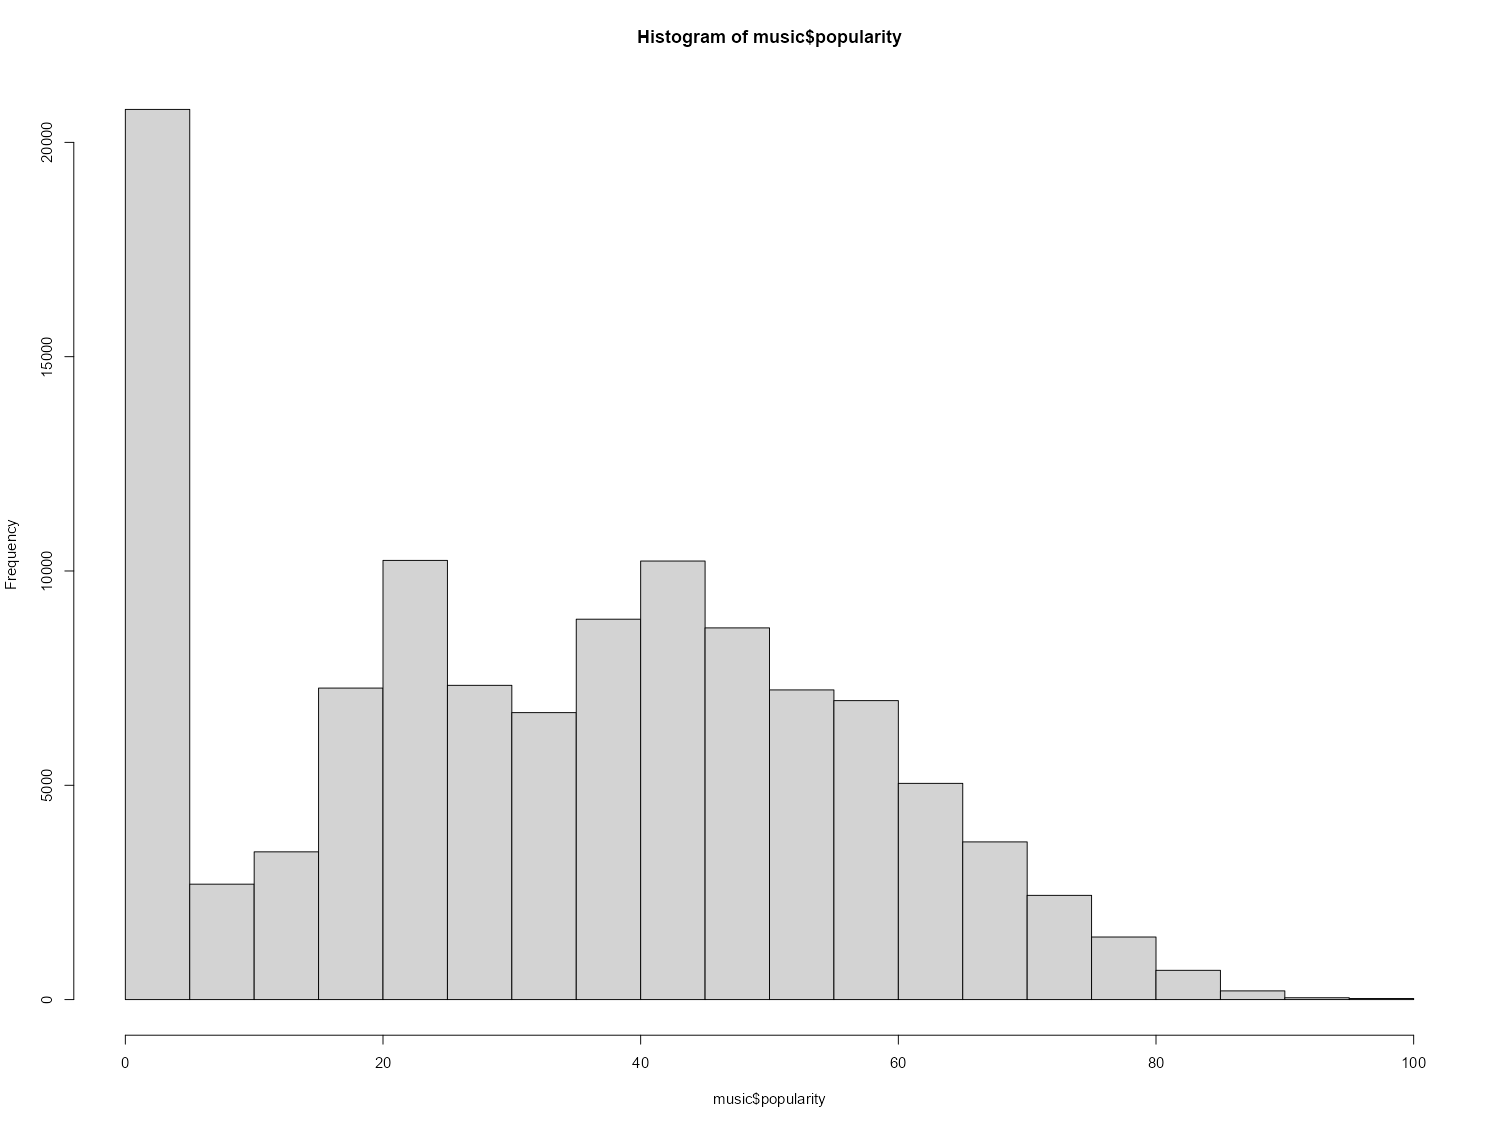

[1] 16020

In [10]:
hist(music$popularity)
# notice a relatively normal distribution EXCEPT for the large amount of low rated songs
nrow(filter(music, popularity == 0)) # check number of songs rated 0

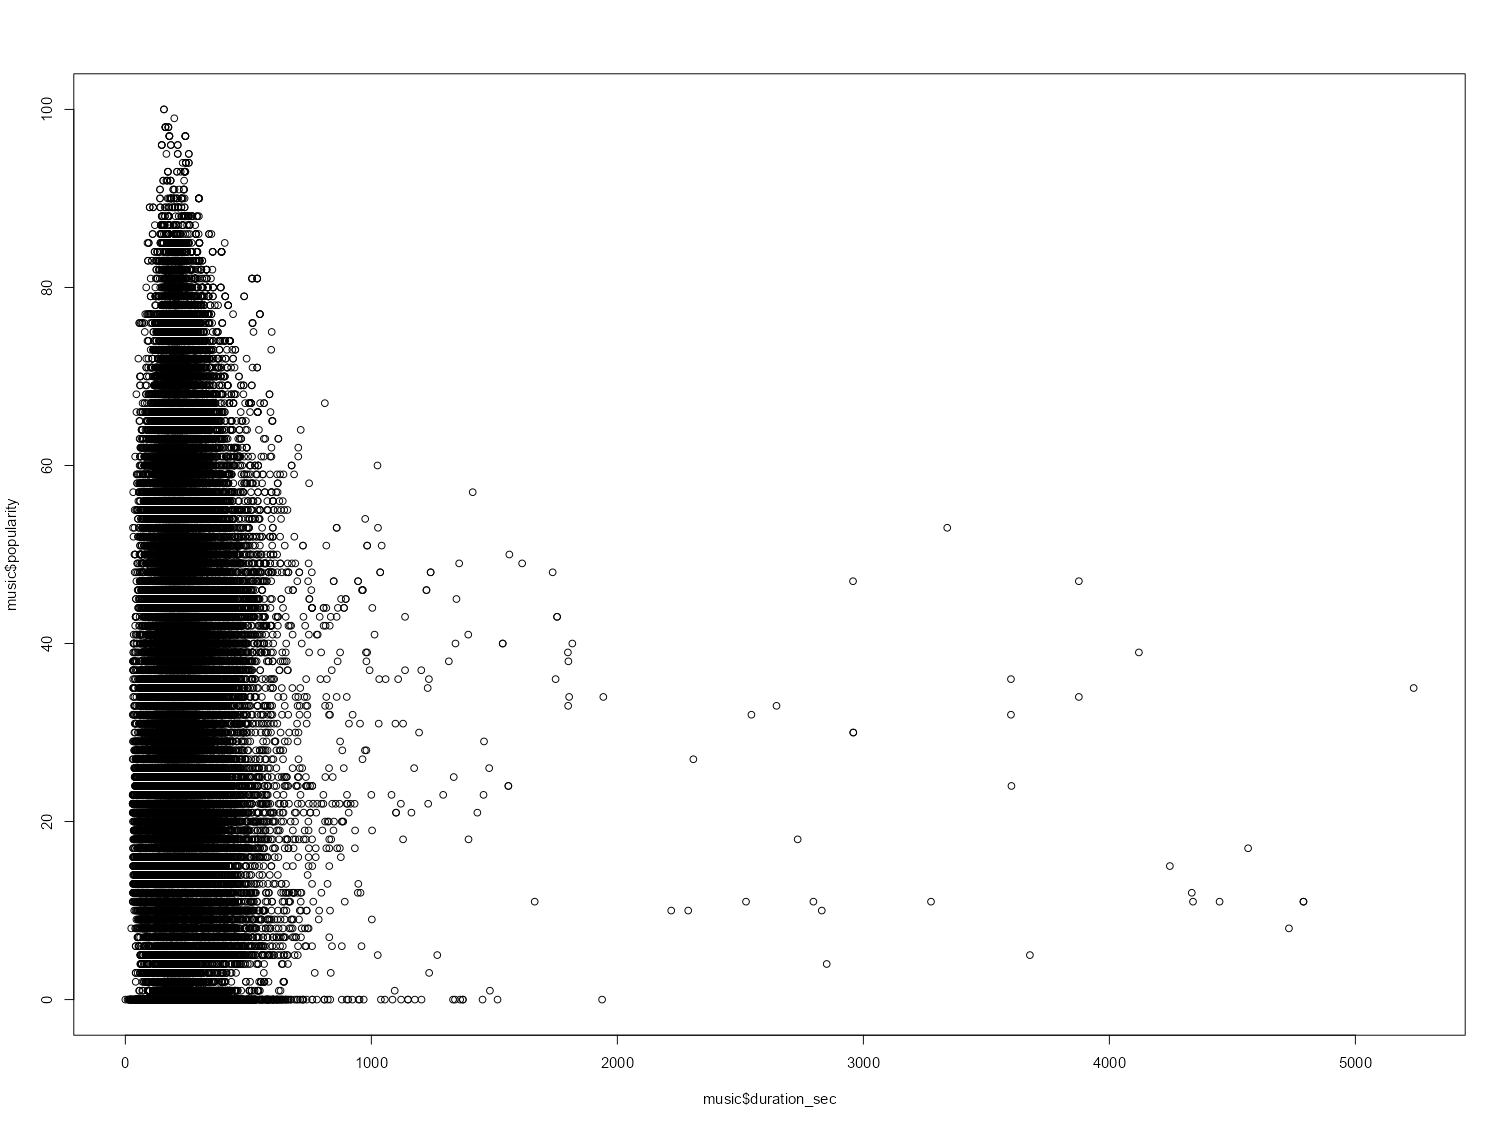

In [11]:
plot(music$duration_sec, music$popularity) # scatterplot of song duration vs popularity

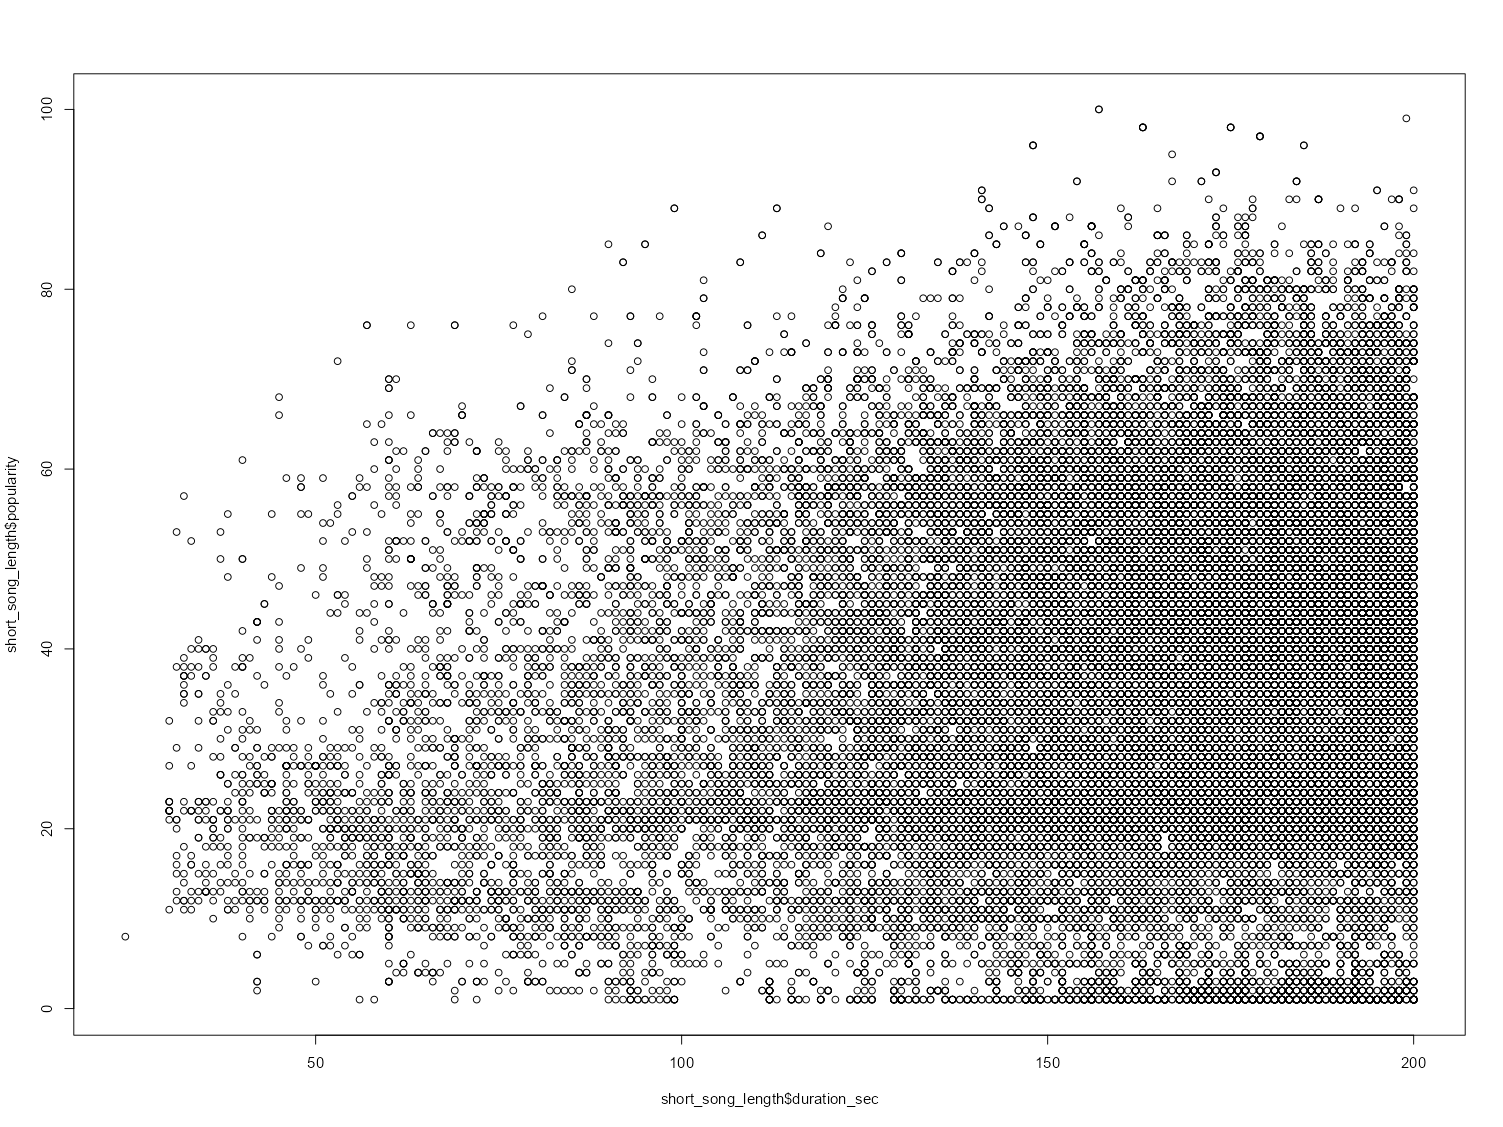

In [12]:
short_song_length <- filter(music, duration_sec <= 200 & popularity > 0)
plot(short_song_length$duration_sec, short_song_length$popularity)

# scatterplot for songs less than 200 seconds and non-zero popularity

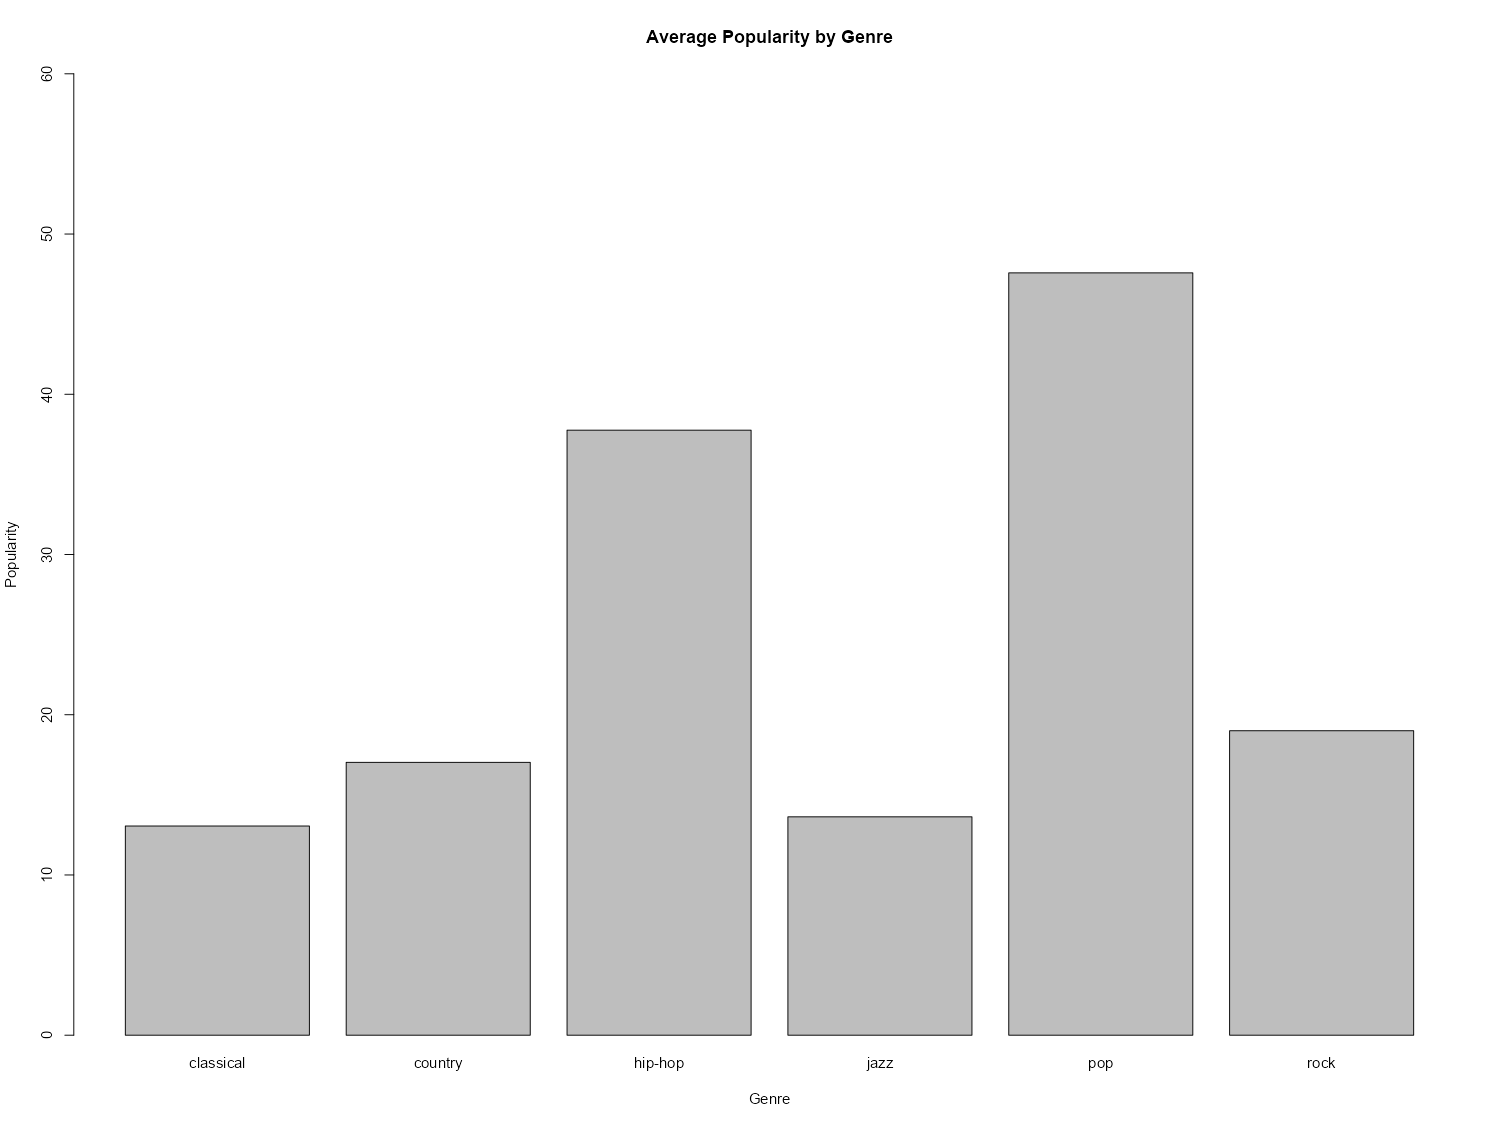

In [13]:
avg_pop <- music %>%
  filter(track_genre %in% c("pop", "rock", "hip-hop", "country", "classical", "jazz")) %>%
  group_by(track_genre) %>%
  summarise(mean_popularity = mean(popularity, na.rm = TRUE))

barplot(avg_pop$mean_popularity, names.arg = avg_pop$track_genre,
  main="Average Popularity by Genre", xlab="Genre", ylab="Popularity", ylim = c(0, 60),)

# barplot of popularity by six major genres

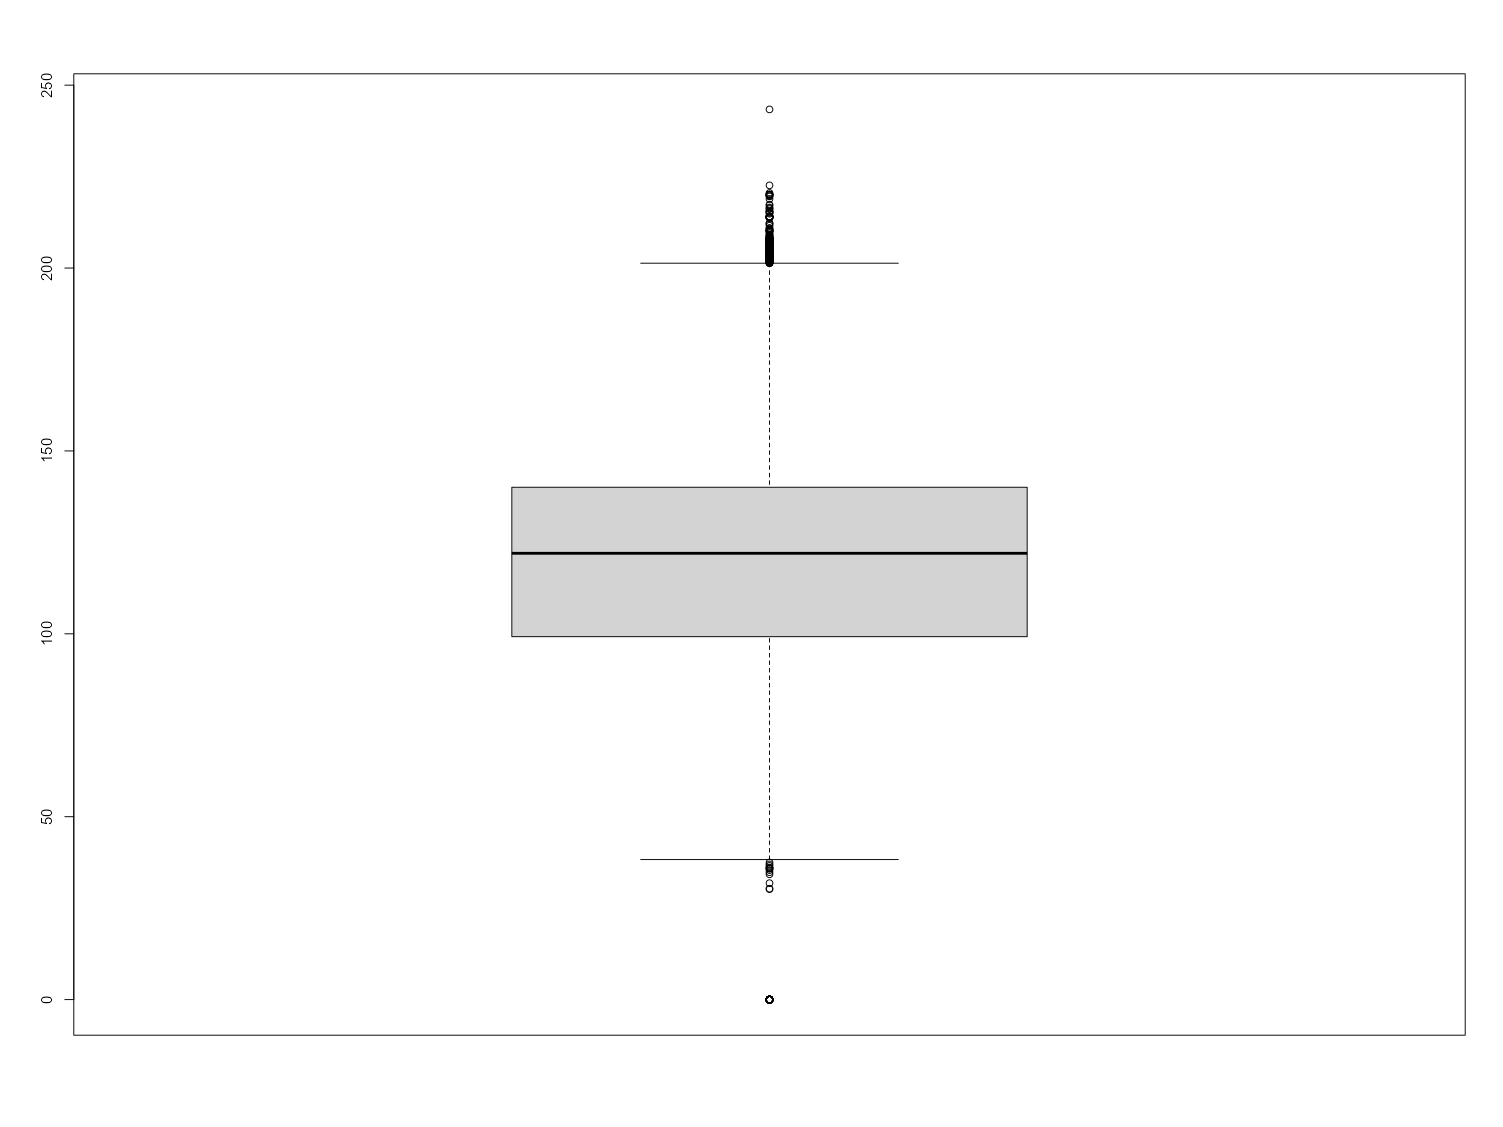

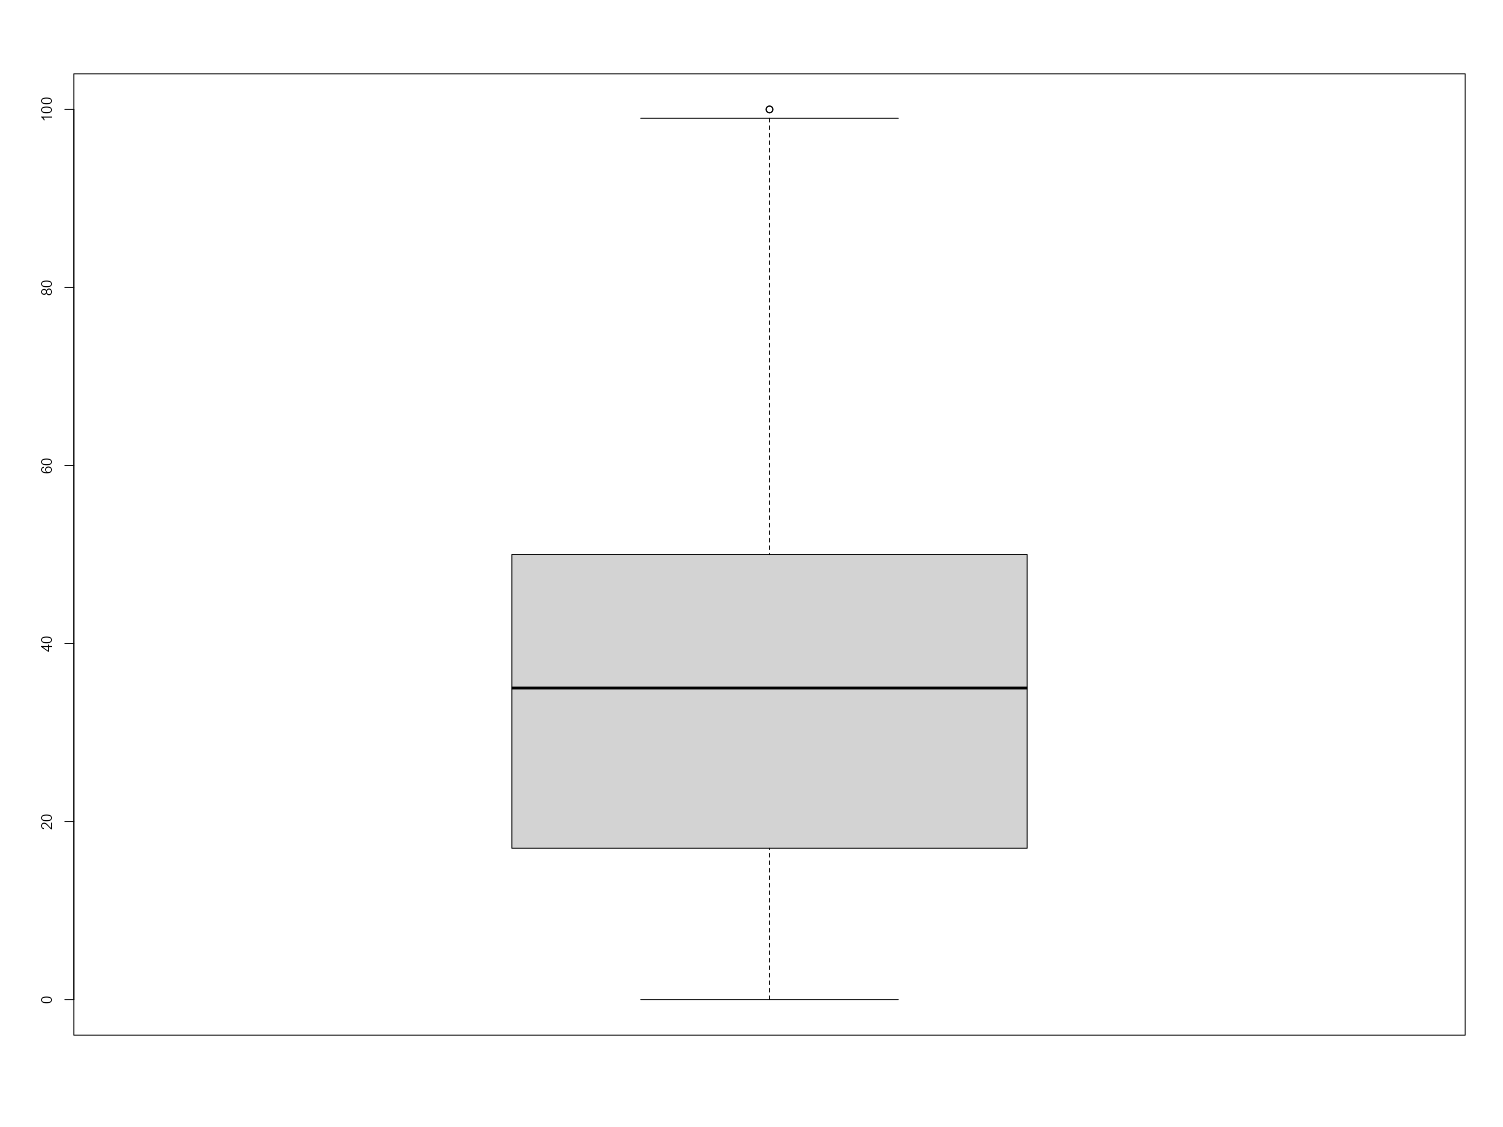

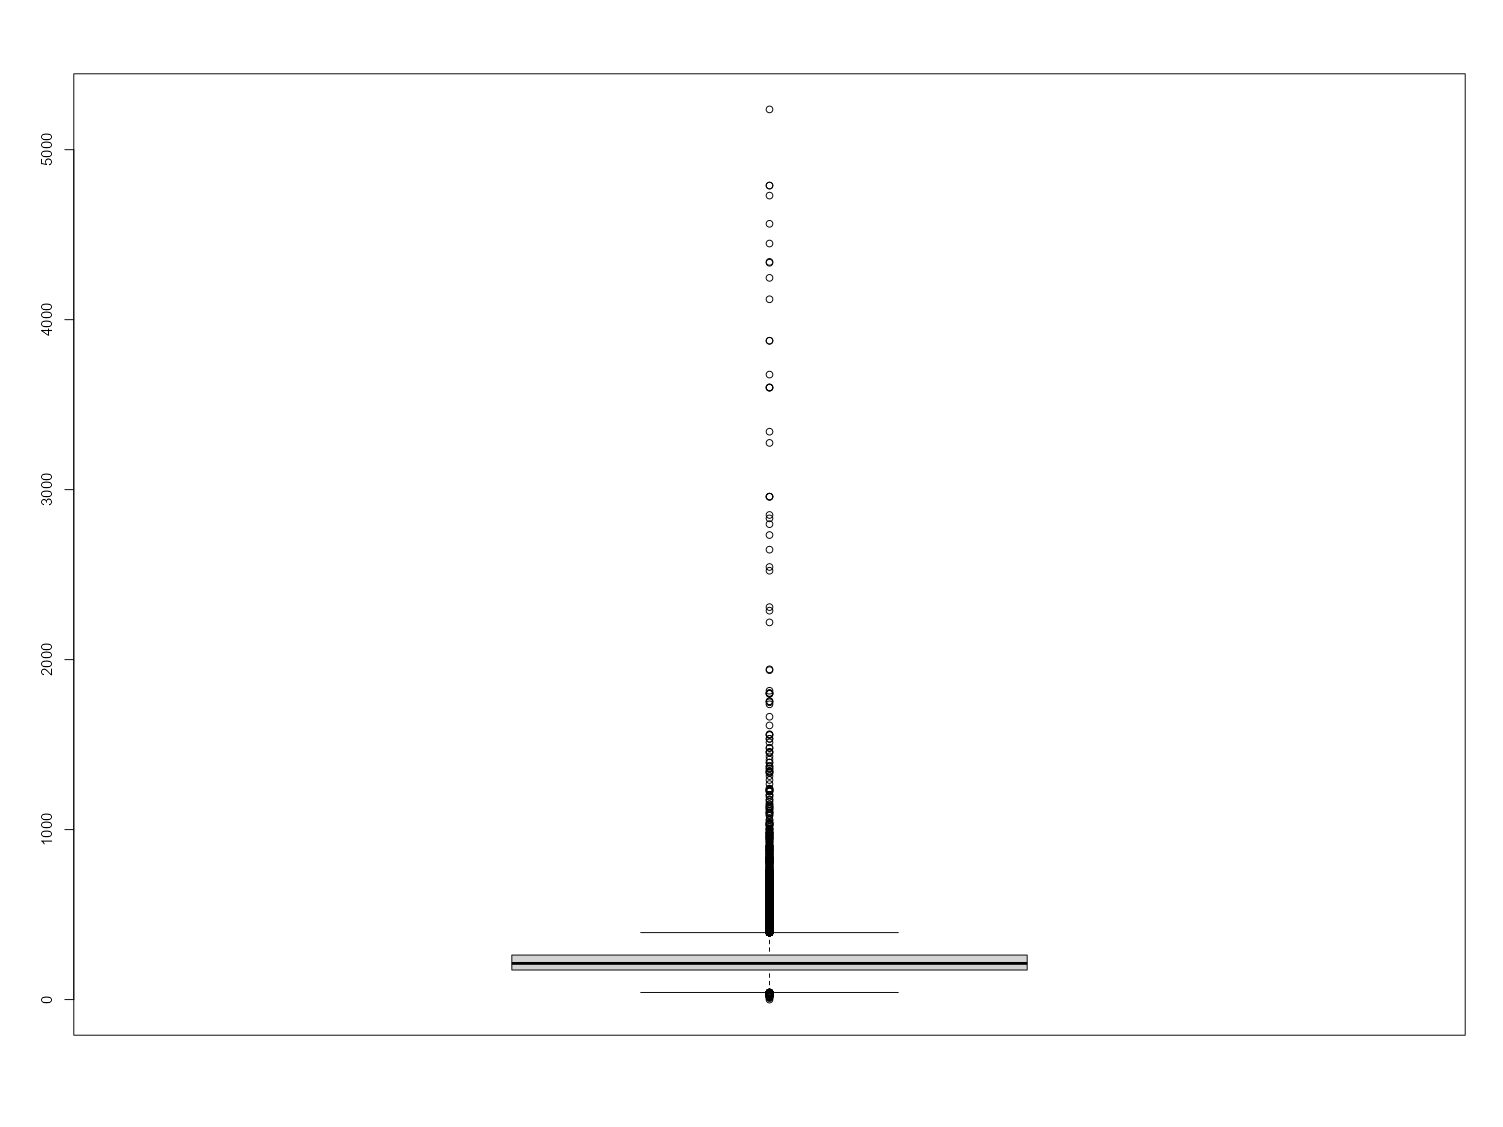

In [14]:
boxplot(music_num$tempo)
boxplot(music_num$popularity)
boxplot(music_num$duration_sec)

# boxplots for our numeric data from earlier
# duration skewed HEAVILY right

In [15]:
round((1 - mean(music_num$mode)) * 100, 2)
# percentage of songs that are in a minor key (mode = 0)
# just to check the proportion of major key songs to minor key songs

[1] 36.24